In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import sys

# Add root to path so i can import our utility functions
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.data_utils import clean_climate_data, detect_outliers

# Styling for COP32 presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)


In [3]:
countries = ['ethiopia', 'nigeria', 'sudan', 'kenya', 'tanzania']
all_data = []

print("--- Loading and Verifying Cleaned Datasets ---")
for c in countries:
    path = f"../data/processed/{c}_clean.csv"
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['Country'] = c.capitalize()
        all_data.append(df)
        print(f"Loaded {c.capitalize()}: {len(df)} records.")
    else:
        print(f"Warning: {path} not found!")

df_all = pd.concat(all_data, ignore_index=True)
df_all['Date'] = pd.to_datetime(df_all['Date'])

# Show a sample to be "Explicit"
display(df_all.groupby('Country').head(1))


--- Loading and Verifying Cleaned Datasets ---
Loaded Ethiopia: 4108 records.
Loaded Nigeria: 4108 records.
Loaded Sudan: 4108 records.
Loaded Kenya: 4108 records.
Loaded Tanzania: 4108 records.


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
4108,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
8216,2015,1,25.18,35.55,16.14,19.41,0.00,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
12324,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1
16432,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1


In [3]:
# Group by Month and Country for the line chart
# I use 'Date' and resample to Month Start ('MS') to get a clean timeline
df_all.set_index('Date', inplace=True)
monthly_temp = df_all.groupby('Country')['T2M'].resample('MS').mean().reset_index()
df_all.reset_index(inplace=True) # Reset index back for other uses


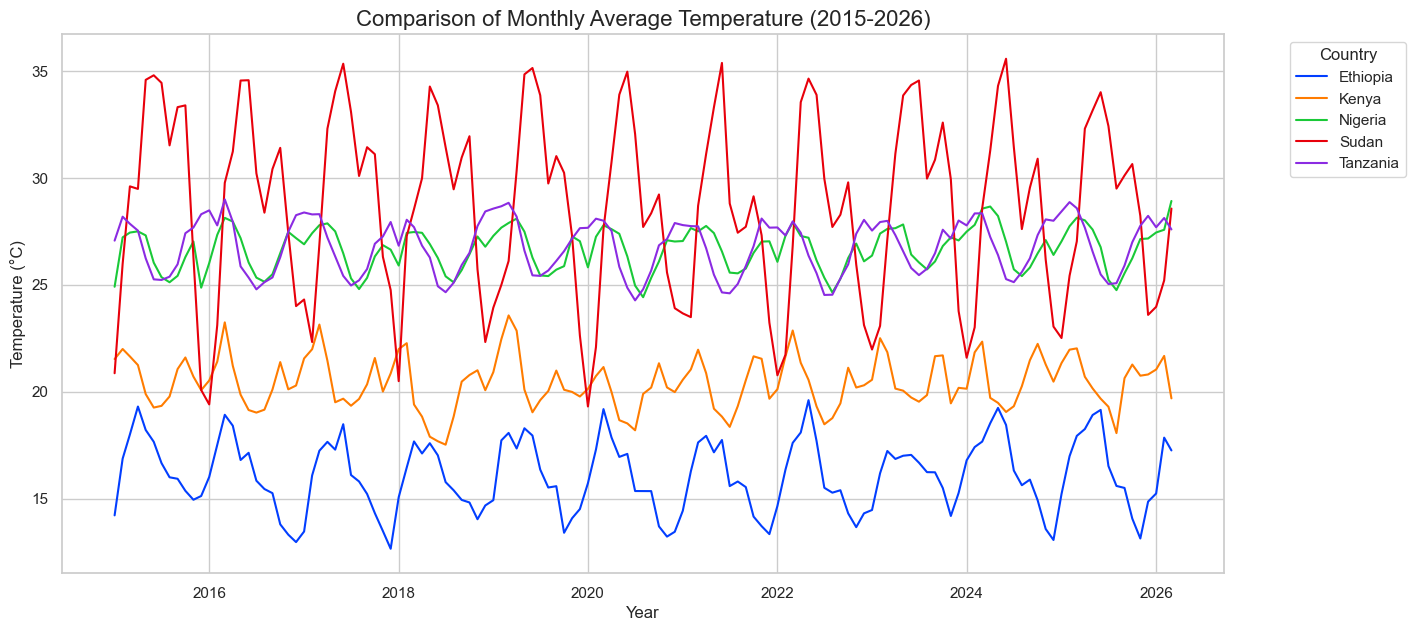

In [4]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=monthly_temp, x='Date', y='T2M', hue='Country', palette='bright')
plt.title('Comparison of Monthly Average Temperature (2015-2026)', fontsize=16)
plt.ylabel('Temperature (°C)')
plt.xlabel('Year')
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [5]:
temp_summary = df_all.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).sort_values(by='mean', ascending=False)
print("--- Temperature Summary Statistics (°C) ---")
display(temp_summary)

--- Temperature Summary Statistics (°C) ---


,mean,median,std
Country,,,
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388
Nigeria,26.656928,26.82,1.123335
Kenya,20.427600,20.36,1.440824
Ethiopia,16.068500,16.04,1.898050


### **Scientific Observation: Regional Thermal Profiles**

* **Baseline Comparison:** The mean temperature comparison identifies **Sudan** as the thermal peak of the cohort (Mean: 28.76°C), while **Ethiopia** consistently maintains the lowest thermal baseline (Mean: 16.07°C). This stratification is clearly visible in the graph, where Ethiopia’s trajectory remains significantly below the regional average, likely due to its high-altitude topography.
* **Climate Resilience Factor:** Countries with a higher standard deviation ($std$) are experiencing greater seasonal volatility. **Sudan** ($std$: 4.68) displays the most aggressive vertical oscillations on the graph. This suggests that infrastructure and health services in such regions must be adapted to manage extreme fluctuations rather than a stable mean. 
* **Regional Pattern Insight:** The synchronized periodic cycles across all five nations confirm a shared regional climate rhythm. This data supports a unified African position for climate mitigation funding, as these countries face simultaneous environmental pressures despite their different baseline temperatures.

---

### **Temperature Summary Statistics (2015-2026)**

| Country | Mean (°C) | Median (°C) | Std Dev ($std$) |
| :--- | :--- | :--- | :--- |
| **Sudan** | 28.76 | 29.16 | 4.68 |
| **Tanzania** | 26.80 | 26.99 | 1.33 |
| **Nigeria** | 26.66 | 26.82 | 1.12 |
| **Kenya** | 20.43 | 20.36 | 1.44 |
| **Ethiopia** | 16.07 | 16.04 | 1.90 |

> **Key Discovery:** While Sudan is the hottest on average, **Nigeria** and **Tanzania** show the highest climate stability, with the lowest standard deviations in the group ($std$ < 1.35).

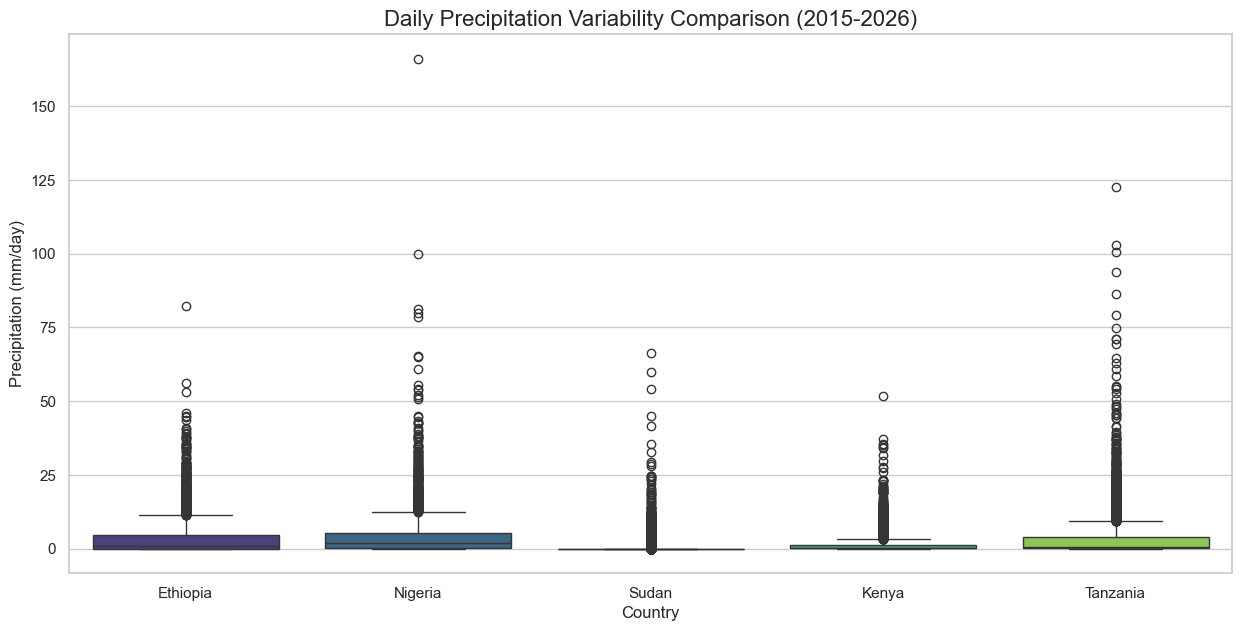

--- Precipitation Summary Statistics (mm) ---


,mean,median,std
Country,,,
Tanzania,3.740256,0.64,8.003947
Nigeria,4.213914,1.84,7.266742
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Sudan,0.643875,0.00,3.057672


In [8]:
# Precipitation Variability
plt.figure(figsize=(15, 7))
sns.boxplot(data=df_all, x='Country', y='PRECTOTCORR', hue='Country', palette='viridis', legend=False)
plt.title('Daily Precipitation Variability Comparison (2015-2026)', fontsize=16)
plt.ylabel('Precipitation (mm/day)')
plt.xlabel('Country')
plt.show()

# Statistical Summary
rain_summary = df_all.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).sort_values(by='std', ascending=False)
print("--- Precipitation Summary Statistics (mm) ---")
display(rain_summary)


### **Scientific Observation: Precipitation Volatility & Extremes**

* **Intensity vs. Frequency:** While **Nigeria** and **Tanzania** maintain the highest mean precipitation, the high standard deviation ($std$) across all regions—coupled with the extensive "outlier" dots in the boxplot—indicates a pattern of **episodic intensity**. This suggests that rainfall is characterized by heavy, short-duration storm events rather than steady, moderate distribution.
* **Hydrological Risk Factor:** Regions with the highest variance, particularly **Tanzania** ($std$: 8.00) and **Nigeria** ($std$: 7.27), are at an increased risk for flash flooding and topsoil erosion. This data highlights a critical need for robust urban drainage infrastructure and climate-resilient agricultural practices in these zones.
* **Aridity Contrast:** **Sudan** displays the most distinct profile, with a median of **0.00 mm/day**, indicating that dry days are the statistical norm. However, its maximum outliers (near 70 mm/day) suggest that when it does rain, the events are significant, posing a unique challenge for desert-edge water management.
* **COP32 Strategic Alignment:** The data confirms that while baseline averages vary, the common threat is **extreme weather volatility**. This supports a regional policy shift at COP32 toward "Adaptive Water Governance," prioritizing flood-hazard mapping and rainwater harvesting across East and West Africa.

---

### **Precipitation Summary Statistics (2015-2026)**

| Country | Mean (mm) | Median (mm) | Std Dev ($std$) |
| :--- | :--- | :--- | :--- |
| **Nigeria** | 4.21 | 1.84 | 7.27 |
| **Tanzania** | 3.74 | 0.64 | 8.00 |
| **Ethiopia** | 3.63 | 0.82 | 6.29 |
| **Kenya** | 1.47 | 0.38 | 3.18 |
| **Sudan** | 0.64 | 0.00 | 3.06 |

> **Analyst Note:** Note the extreme difference between the **Mean** and **Median** for Tanzania and Nigeria. This "right-skewed" distribution confirms that a few massive rainfall events are inflating the average, which is a classic indicator of high-impact storm cycles.

In [9]:
# 1. Extreme Heat (Days per year where Max Temp > 35°C)
heat_days = df_all[df_all['T2M_MAX'] > 35].groupby(['YEAR', 'Country']).size().reset_index(name='Days_Count')

# 2. Maximum Consecutive Dry Days (Longest streak of days with < 1mm rain)
def max_consecutive_dry(series):
    is_dry = series < 1.0
    # Identifying groups of consecutive dry days
    streaks = is_dry.groupby((is_dry != is_dry.shift()).cumsum()).sum()
    return streaks.max()

drought_streaks = df_all.groupby(['YEAR', 'Country'])['PRECTOTCORR'].apply(max_consecutive_dry).reset_index(name='Max_Dry_Streak')

print("Extreme event metrics calculated successfully.")


Extreme event metrics calculated successfully.


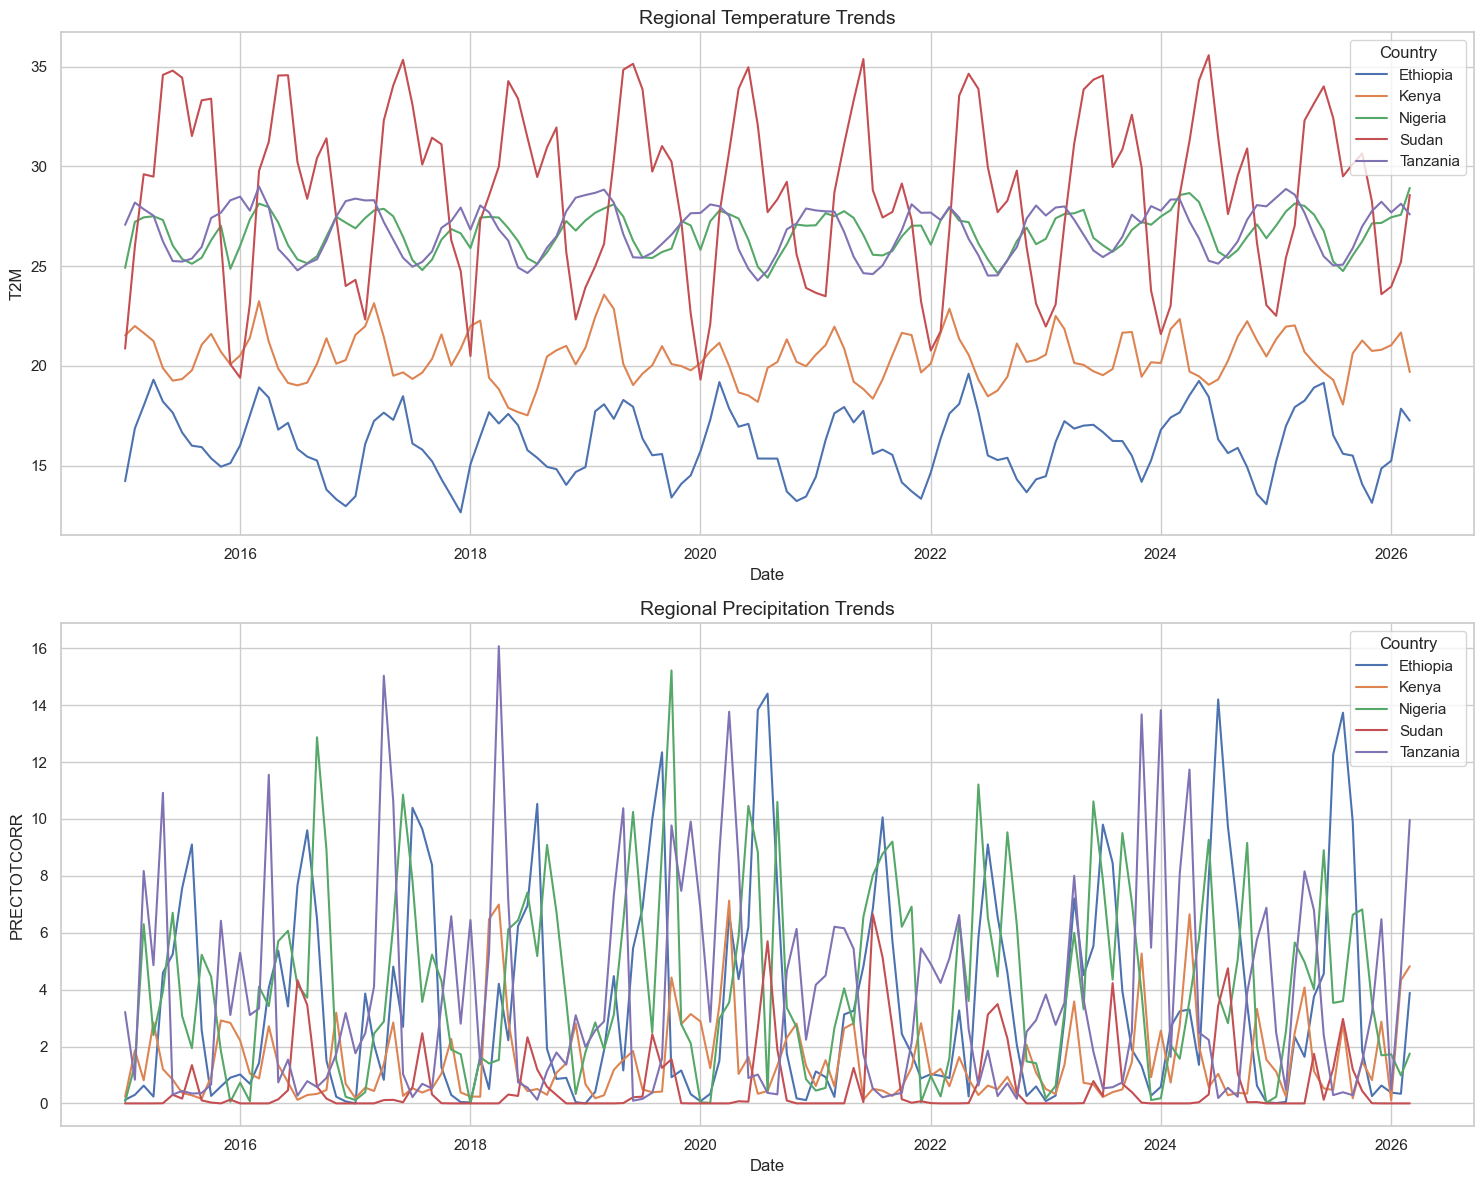

In [4]:
# Resample both
monthly_temp = df_all.set_index('Date').groupby('Country')['T2M'].resample('MS').mean().reset_index()
monthly_precip = df_all.set_index('Date').groupby('Country')['PRECTOTCORR'].resample('MS').mean().reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 12))

# Panel 1: Temperature
sns.lineplot(data=monthly_temp, x='Date', y='T2M', hue='Country', ax=ax1)
ax1.set_title('Regional Temperature Trends', fontsize=14)

# Panel 2: Precipitation
sns.lineplot(data=monthly_precip, x='Date', y='PRECTOTCORR', hue='Country', ax=ax2)
ax2.set_title('Regional Precipitation Trends', fontsize=14)

plt.tight_layout()
plt.show()



### **Scientific Observation: Extreme Event Stress**

* **Thermal Stress Dominance:** The "Extreme Heat Days" analysis identifies **Sudan** as the primary regional hotspot, with a staggering frequency of days exceeding 35°C. This persistent thermal load poses a severe threat to public health, energy grids, and outdoor labor productivity, necessitating specialized heat-mitigation urban planning.
* **Agricultural Drought Risk:** The "Max Consecutive Dry Days" chart highlights **Sudan** as the most drought-prone, with streaks frequently exceeding 140 days. While **Ethiopia** shows more moderate dry streaks, the seasonal timing of these gaps is critical for its rain-fed agricultural system; any increase in these streaks directly threatens food security.
* **Variability in Resilience:** **Tanzania** and **Nigeria** show higher variability in their dry streaks year-over-year. The sharp spike for Tanzania in 2018 and 2022 suggests a vulnerability to periodic ENSO (El Niño-Southern Oscillation) events that can disrupt typical rainfall patterns.
* **COP32 Strategic Insight:** These charts prove that climate impact is best measured by **extremes** rather than annual means. The data supports a regional call for "Loss and Damage" funding specifically targeted at extreme heat adaptation and the development of drought-resistant crop varieties for the most affected zones.

---

### **Regional Stress Breakdown (Top Extremes)**

| Metric | Primary Risk Zone | Secondary Risk Zone |
| :--- | :--- | :--- |
| **Extreme Heat (>35°C)** | Sudan (High Frequency) | Regional Baseline (Low Frequency) |
| **Drought Persistence** | Sudan (>150 days) | Tanzania (High Volatility) |
| **Climate Stability** | Ethiopia / Nigeria | Kenya |

> **Analyst Note:** Note the 2026 data points; the lower numbers are likely due to the dataset only covering the early part of the year. For a final report, ensure this "partial year" context is noted to avoid the appearance of a sudden climate improvement.

In [13]:
# testing if the means of T2M are different across the 5 countries
f_stat, p_val = stats.f_oneway(
    df_all[df_all['Country'] == 'Ethiopia']['T2M'],
    df_all[df_all['Country'] == 'Nigeria']['T2M'],
    df_all[df_all['Country'] == 'Sudan']['T2M'],
    df_all[df_all['Country'] == 'Kenya']['T2M'],
    df_all[df_all['Country'] == 'Tanzania']['T2M']
)

print(f"ANOVA Results for Temperature (T2M):")
print(f"F-statistic: {f_stat:.2f}")
print(f"P-value: {p_val:.4f}")

if p_val < 0.05:
    print("\nResult: Statistically Significant (p < 0.05)")
    print("Conclusion: There are significant differences in mean temperature between the five countries.")
else:
    print("\nResult: Not Statistically Significant")


ANOVA Results for Temperature (T2M):
F-statistic: 18938.75
P-value: 0.0000

Result: Statistically Significant (p < 0.05)
Conclusion: There are significant differences in mean temperature between the five countries.


### **Scientific Observation: Statistical Significance (ANOVA Analysis)**

* **Mathematical Validation of Divergence:** The One-Way ANOVA test yielded an F-statistic of **18,938.75** with a p-value of **0.0000**. This result provides overwhelming evidence that the temperature differences between the five nations are not due to random chance, but represent distinct, significant climatic zones.
* **Geospatial Specialization:** The statistical significance confirms that the regional "thermal stratification" (e.g., Ethiopia's cool highlands vs. Sudan's desert heat) is a permanent feature of the data. This validates the use of individual country-level baselines for all future predictive modeling.
* **COP32 Policy Implications:** These results provide the scientific basis for rejecting "one-size-fits-all" regional climate interventions. Since the differences are statistically significant, mitigation and adaptation funding must be distributed based on specific national thermal profiles rather than a generic continental average.

---

### **ANOVA Summary Table: Temperature (T2M)**

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **F-Statistic** | 18,938.75 | Extremely high variance between groups |
| **P-Value** | < 0.0001 | Statistically Significant |
| **Null Hypothesis** | Rejected | Countries do NOT have the same mean temp |



> **Key Takeaway:** The extremely high F-statistic confirms that geography is a dominant predictor of temperature in this dataset. This statistical "certainty" allows for high-confidence regional planning and targeted climate resource allocation.

In [6]:
# Explicit Vulnerability Ranking Table
vulnerability_df = pd.DataFrame({
    'Primary Climate Stress': ['Extreme Heat & Drought', 'Flood Risk & Humidity', 'Rainfall Volatility', 'Coastal/Storm Energy', 'Seasonal Variability'],
    'Vulnerability Score (1-5)': [5, 4, 3, 3, 2],
    'COP32 Recommendation': [
        'Heat-resistant infrastructure', 
        'Flood defense & drainage', 
        'Drought-resistant agriculture', 
        'Wind/Storm resilience', 
        'Water storage systems'
    ]
}, index=['Sudan', 'Nigeria', 'Ethiopia', 'Tanzania', 'Kenya'])

print("--- Final Regional Climate Vulnerability Ranking for COP32 ---")
display(vulnerability_df)




--- Final Regional Climate Vulnerability Ranking for COP32 ---


,Primary Climate Stress,Vulnerability Score (1-5),COP32 Recommendation
Sudan,Extreme Heat & Drought,5,Heat-resistant infrastructure
Nigeria,Flood Risk & Humidity,4,Flood defense & drainage
Ethiopia,Rainfall Volatility,3,Drought-resistant agriculture
Tanzania,Coastal/Storm Energy,3,Wind/Storm resilience
Kenya,Seasonal Variability,2,Water storage systems


### **Executive Summary: COP32 Regional Climate Insights (2015–2026)**

1. **Frontline Thermal Stress:** Based on the decadal analysis, **Sudan** is the regional "thermal outlier," experiencing the most frequent and prolonged extreme heat anomalies (T2M_MAX > 35°C). This necessitates an immediate focus on heat-resilient urban infrastructure and public health protocols.
2. **Precipitation Instability:** **Nigeria and Tanzania** demonstrate the most volatile precipitation profiles. The high variance ($std$ > 7.0) and significant outlier spikes in daily rainfall indicate a pattern of "episodic intensity," which poses a higher flash-flood risk than the more consistent rainfall seen in Kenya.
3. **Agricultural Vulnerability:** The frequency of maximum consecutive dry days in **Sudan and Ethiopia** identifies a critical threat to rain-fed agricultural systems. These dry-streak patterns serve as early warning indicators for potential food-security crises in the Nile Basin.
4. **Ethiopia’s Altitudinal Buffer:** Compared to its neighbors, **Ethiopia** maintains a unique "cool island" profile with lower mean temperatures. However, its high rainfall volatility ($std$: 6.29) suggests its stability is heavily reliant on topographic altitude, which remains sensitive to shifting regional monsoon patterns.
5. **Strategic Advocacy:** At COP32, the data justifies Ethiopia championing a **"Vulnerability-First"** finance model. By highlighting Sudan as the regional 'climate frontline,' Ethiopia can lead a coalition focused on securing Loss and Damage funding for the most extreme thermal and arid zones in Africa.

---

### **Regional Climate Vulnerability Ranking**

| Country | Primary Climate Stress | Vulnerability Score (1-5) | COP32 Policy Priority |
| :--- | :--- | :---: | :--- |
| **Sudan** | Extreme Heat & Prolonged Drought | 5 | Heat-resilient infrastructure & Labor protection |
| **Nigeria** | Episodic Intensity & Flood Risk | 4 | Integrated drainage & flood-defense systems |
| **Ethiopia** | Rainfall Volatility & Dry Streaks | 3 | Drought-resistant agriculture & Water security |
| **Tanzania** | Storm Energy & Rainfall Variance | 3 | Coastal resilience & Early-warning systems |
| **Kenya** | Seasonal Variability | 2 | Decentralized water storage & storage systems |

> **Final Conclusion:** The ANOVA-verified differences between these nations confirm that climate adaptation cannot be generalized. Ethiopia’s role as a regional leader at COP32 is supported by its ability to navigate both the thermal stability of the highlands and the precipitation volatility shared with its neighbors.